In [2]:
import warnings
warnings.filterwarnings('ignore')

# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.base import BaseEstimator, RegressorMixin, clone
import joblib
from scipy.stats import chi2
import random
from scipy.optimize import differential_evolution

# Optional: SHAP for model explainability (will be used if installed)
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


In [3]:
# 2. Load dataset
FILE = "data.xlsx"
SHEET = 0

try:
    df = pd.read_excel(FILE, sheet_name=SHEET)
except Exception as e:
    raise SystemExit(f"Failed to read {FILE}: {e}")

# drop No. column if exists (case-insensitive)
for col in df.columns:
    if str(col).strip().lower() in ["no.", "no", "number", "index"]:
        df.drop(columns=[col], inplace=True)
        break

print(f"Dataset shape: {df.shape}")


Dataset shape: (188, 8)


In [4]:
# 3. Quick data check and cleaning
print("\nFirst 5 rows:")
print(df.head())

print("\nData types:\n", df.dtypes)

missing = df.isnull().sum()
print("\nMissing values per column:\n", missing[missing > 0])

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

if df[num_cols].isnull().any().any():
    print("\nImputing numeric missing values with median")
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

if len(cat_cols) > 0 and df[cat_cols].isnull().any().any():
    print("\nImputing categorical missing values with mode")
    for c in cat_cols:
        df[c] = df[c].fillna(df[c].mode().iloc[0])




First 5 rows:
   Q(m)  GPM     p(g)  T(g)  RPM   D(b)  W.O.B       H    ROP
0       70.0  11.9690  29.4  100  12.25   17.5  1561.0   4.84
1       60.0  12.3525  27.4   85  12.25   19.0  1041.0   2.81
2      110.0  12.2366  28.7   90  12.25   12.5   950.0  10.00
3       65.0  12.3525  27.4   90  12.25   19.0  1268.0   4.14
4       95.0  12.4091  21.6  105  12.25   27.5  1138.0  10.15

Data types:
 Q(m)  GPM    float64
p(g)         float64
T(g)         float64
RPM            int64
D(b)         float64
W.O.B        float64
H            float64
ROP          float64
dtype: object

Missing values per column:
 Series([], dtype: int64)


In [5]:
# 4. Descriptive statistics (stronger)
pd.set_option('display.max_columns', None)

desc = df.describe().T
desc['skew'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurtosis()

print("\nEnhanced descriptive statistics:")
print(desc)




Enhanced descriptive statistics:
           count         mean         std      min       25%        50%  \
Q(m)  GPM  188.0    84.856383   19.346285  60.0000   70.0000    80.0000   
p(g)       188.0    12.329846    0.342226  11.6182   12.2366    12.3525   
T(g)       188.0    22.826064    6.296482   9.0000   16.9000    21.6000   
RPM        188.0   103.882979   15.695196  65.0000   95.0000   105.0000   
D(b)       188.0    15.753989    4.666446  12.2500   12.2500    12.2500   
W.O.B      188.0    16.779255    4.725677   2.5000   12.5000    17.5000   
H          188.0  1356.402660  646.013413  84.0000  804.5000  1332.5000   
ROP        188.0     5.098670    2.297638   0.6900    3.4075     4.7400   

                 75%        max      skew  kurtosis  
Q(m)  GPM   100.0000   140.0000  1.042057  0.239796  
p(g)         12.4091    13.1877  0.593720  1.043023  
T(g)         28.7000    33.6000 -0.167682 -1.135493  
RPM         110.0000   150.0000  0.597821  1.193586  
D(b)         17.5000


Target distribution summary:
count    188.000000
mean       5.098670
std        2.297638
min        0.690000
25%        3.407500
50%        4.740000
75%        6.677500
max       10.370000
Name: ROP, dtype: float64


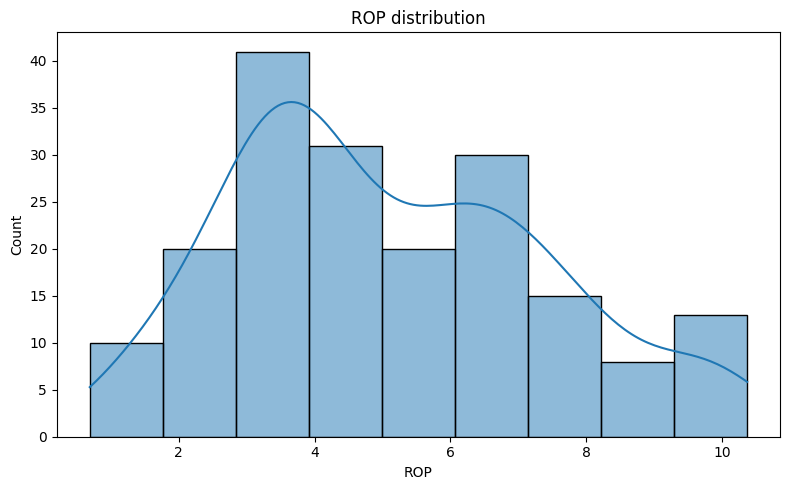

Target skewness: 0.414


In [6]:
# 5. Target check and possible transform
TARGET = 'ROP'
if TARGET not in df.columns:
    raise SystemExit(f"Target column '{TARGET}' not found in dataset")

print("\nTarget distribution summary:")
print(df[TARGET].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df[TARGET], kde=True)
plt.title('ROP distribution')
plt.tight_layout()
plt.savefig('ROP_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

target_skew = df[TARGET].skew()
print(f"Target skewness: {target_skew:.3f}")

# (kept as you wrote: not auto-transforming, only optional if you enable later)
if (df[TARGET] > 0).all():
    pt = PowerTransformer(method='yeo-johnson')
else:
    pt = PowerTransformer(method='yeo-johnson')




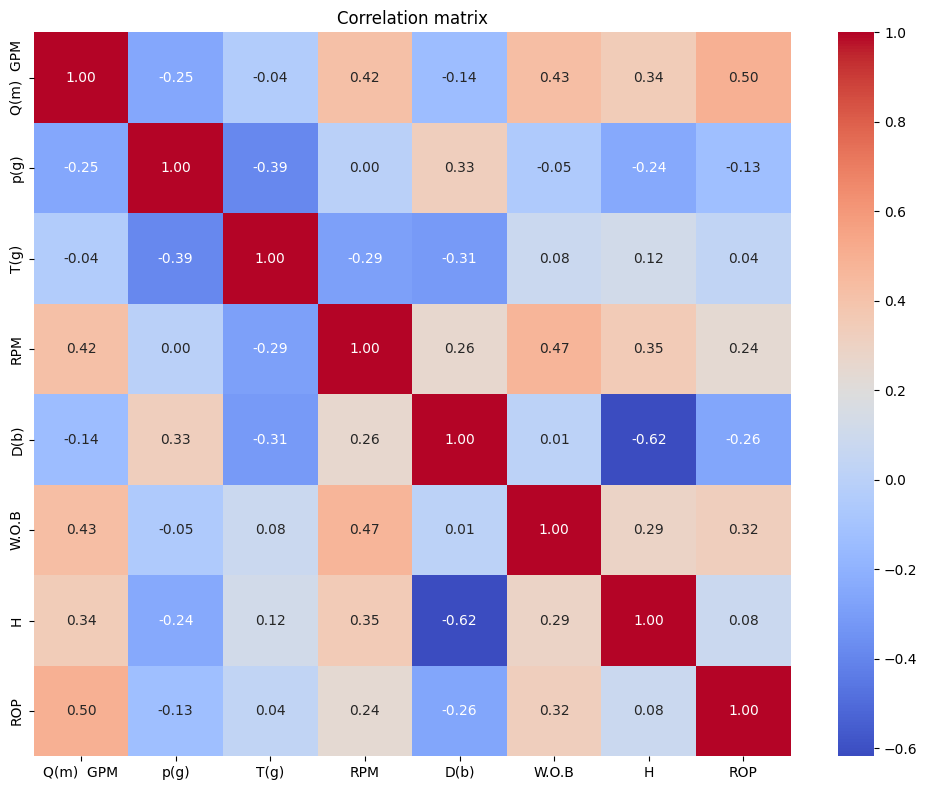

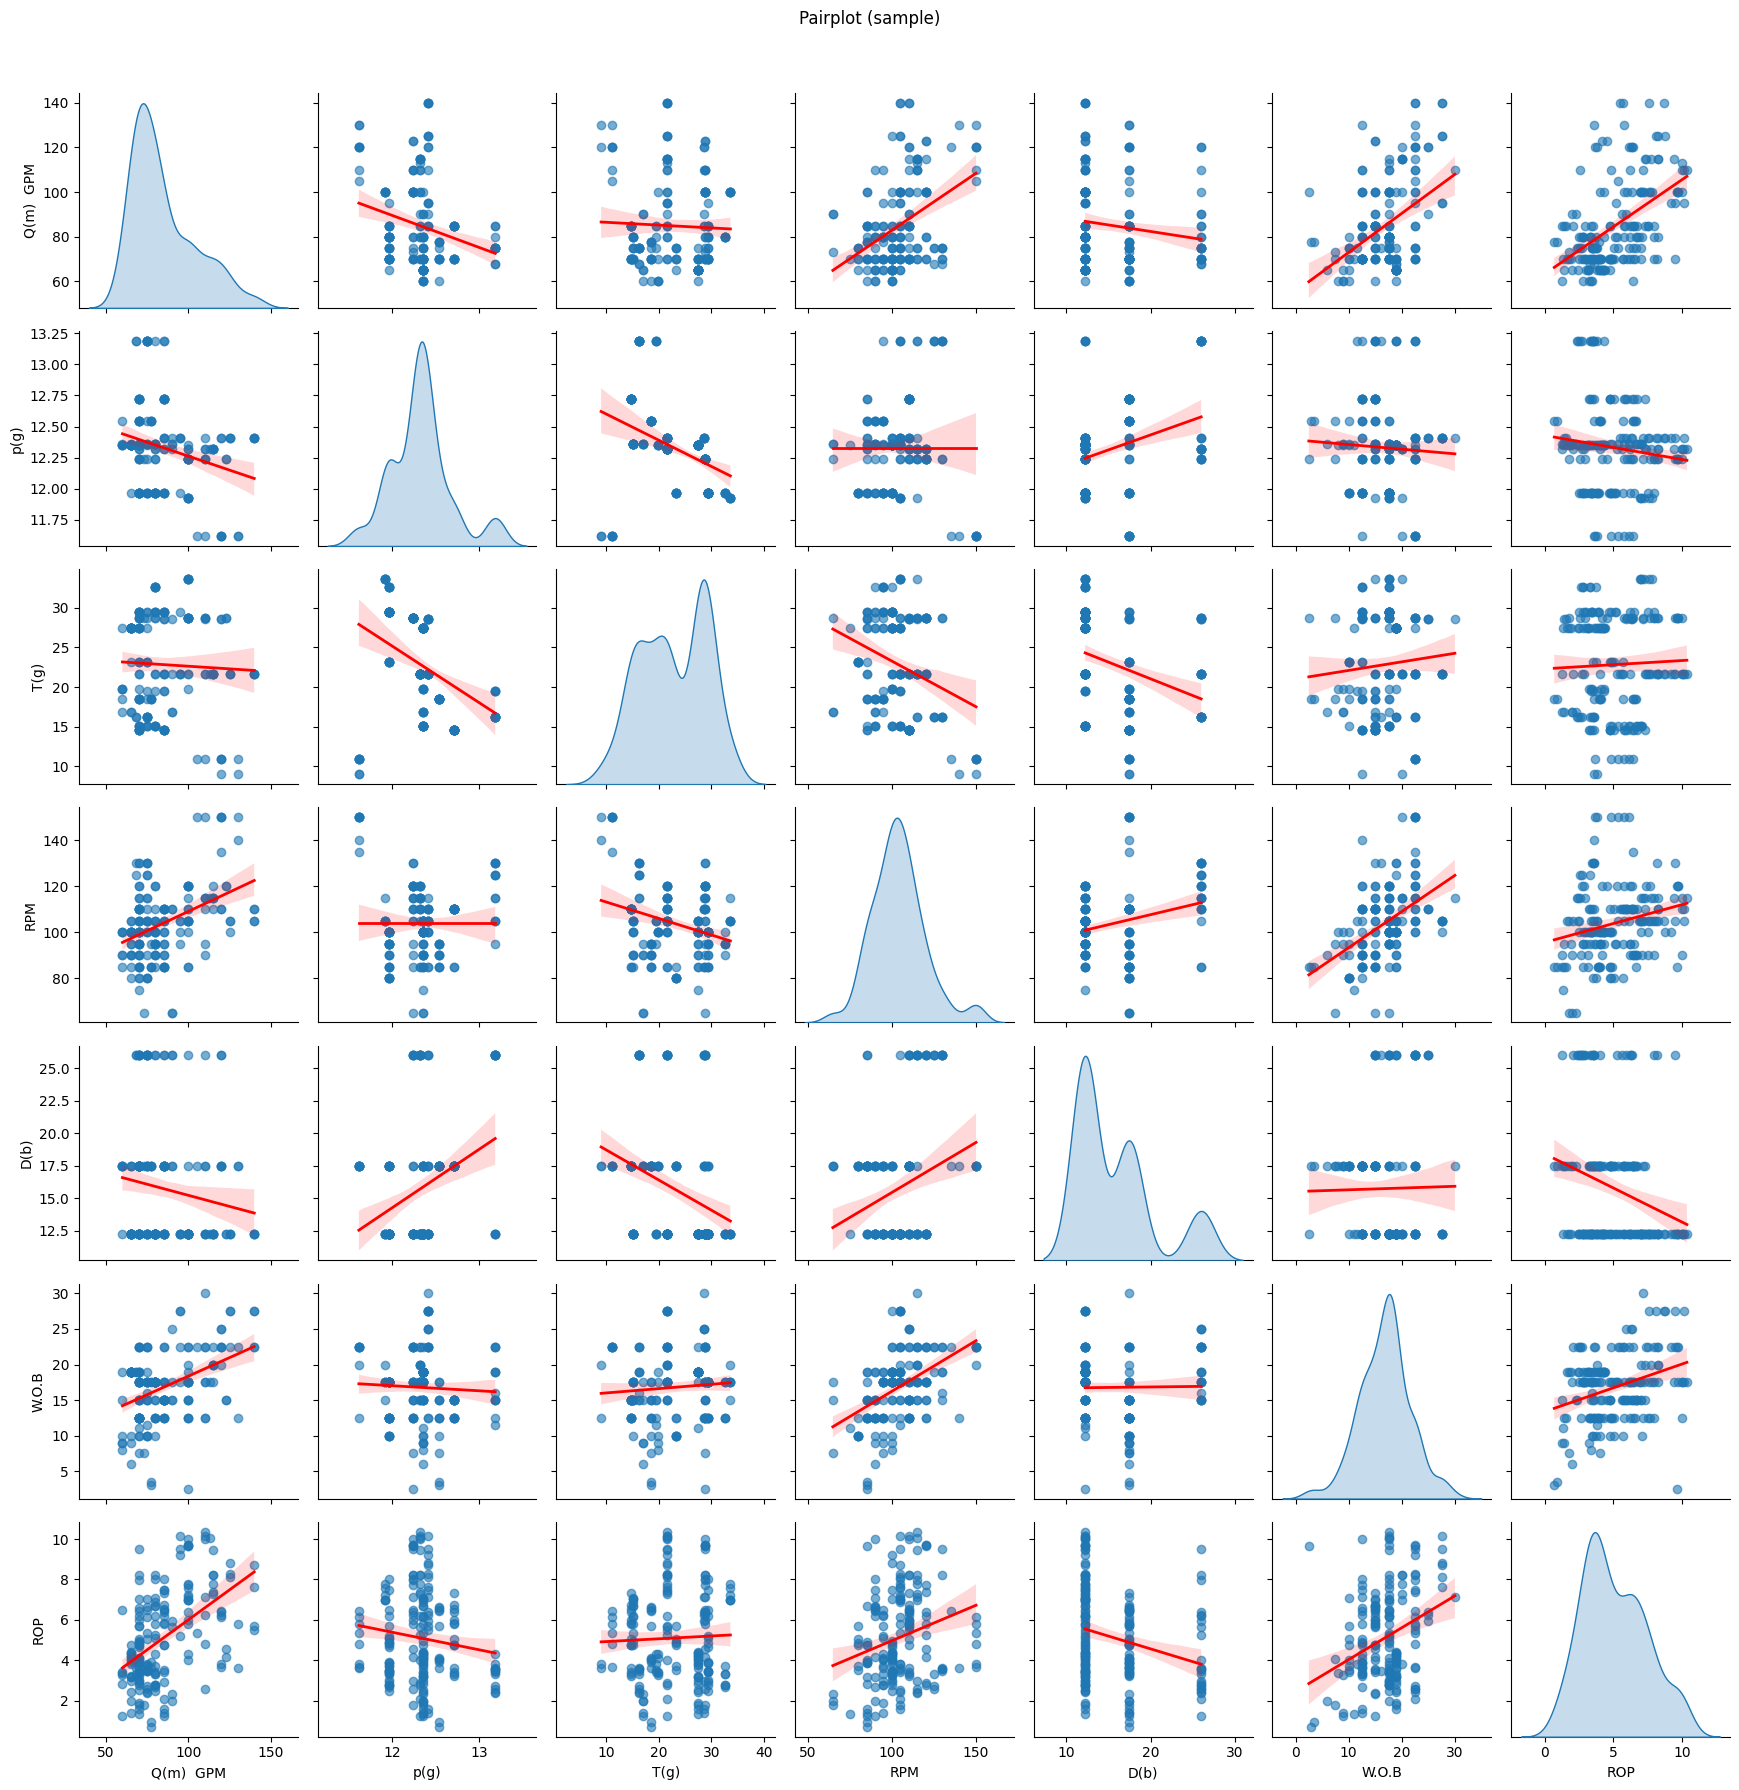

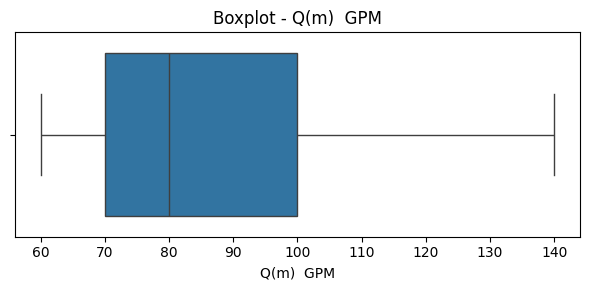

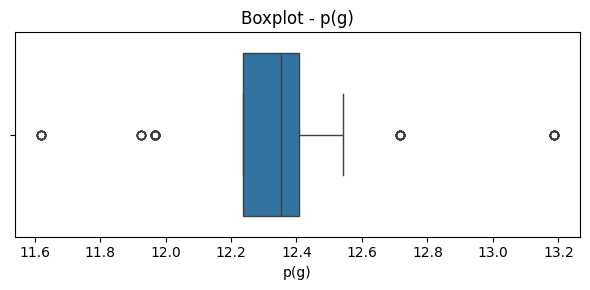

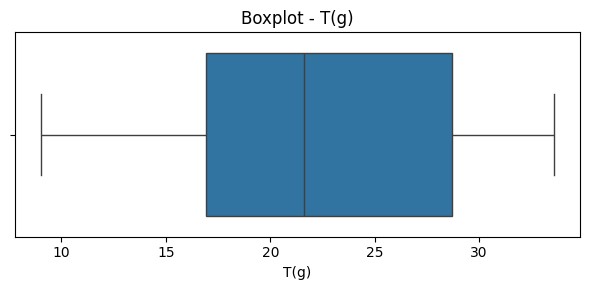

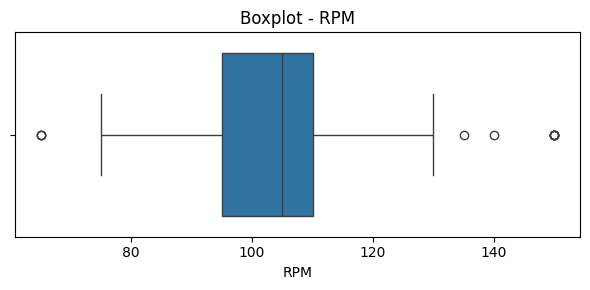

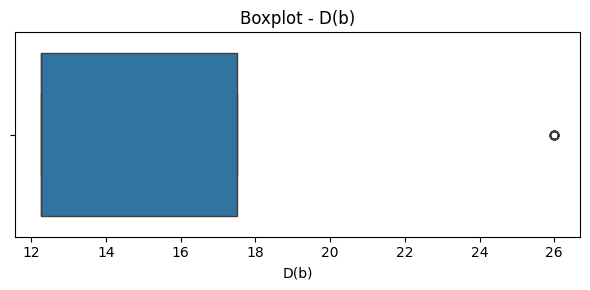

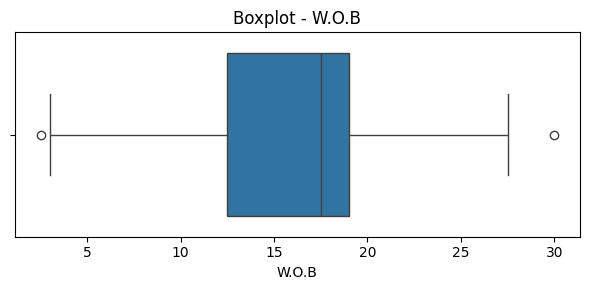

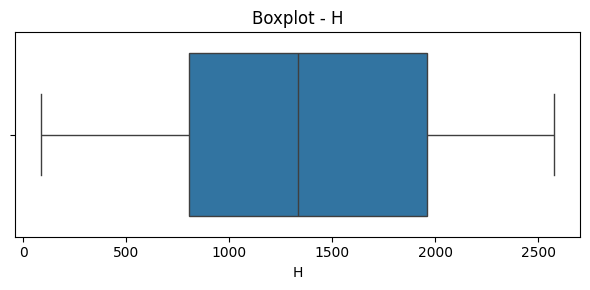

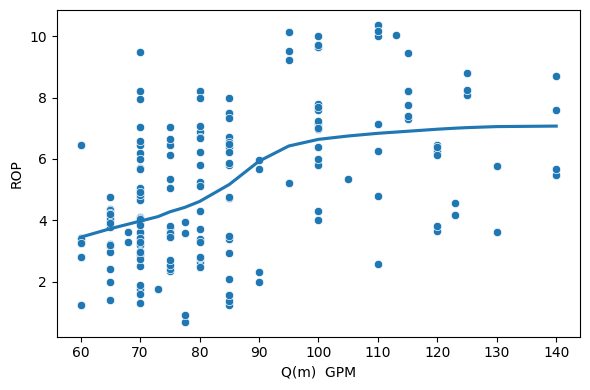

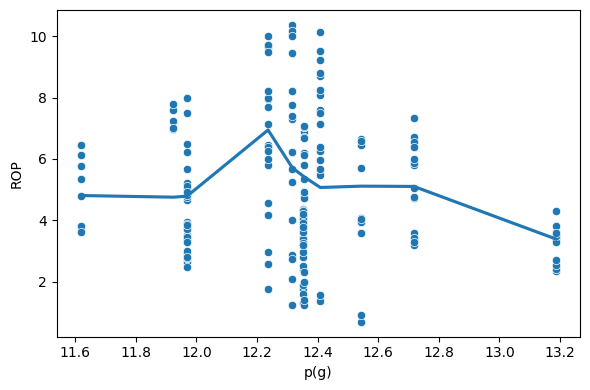

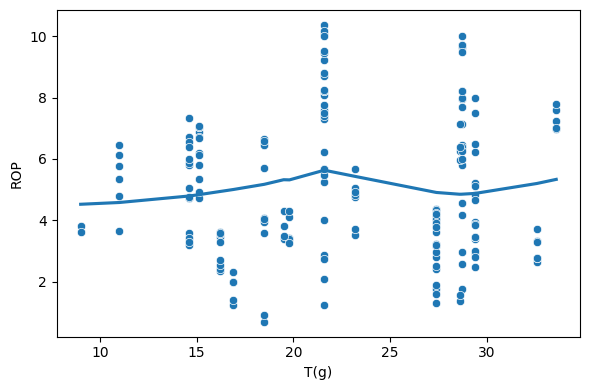

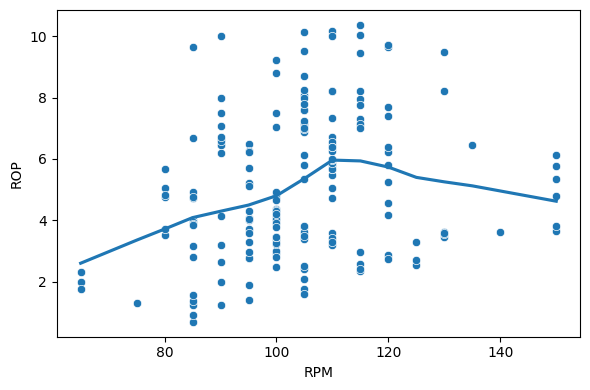

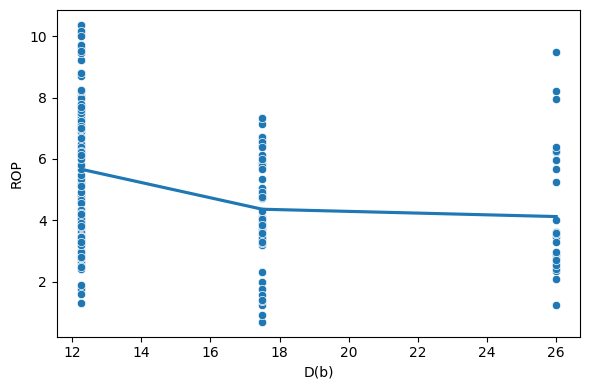

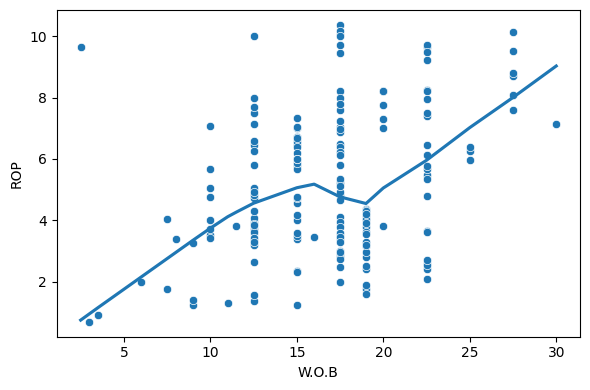

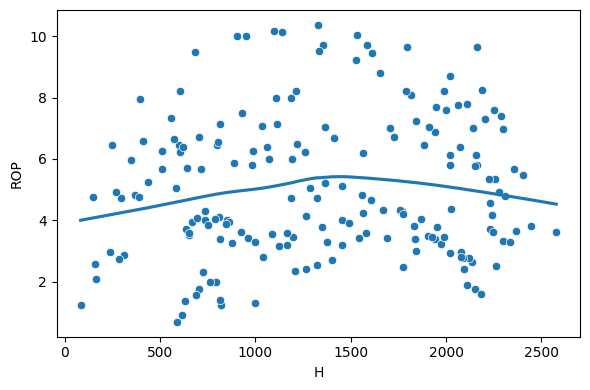

In [7]:
# 6. EDA visualizations
EDA_SAMPLE = df.sample(n=min(1000, len(df)), random_state=RANDOM_STATE)

numeric = num_cols.copy()
if TARGET in numeric:
    numeric.remove(TARGET)

corr = df[numeric + [TARGET]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('Correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

MAX_PAIR = 6
pair_features = numeric[:MAX_PAIR] + [TARGET]
if len(pair_features) > 1:
    g = sns.pairplot(
        EDA_SAMPLE[pair_features],
        diag_kind='kde',
        kind='reg',
        plot_kws={'scatter_kws': {'alpha': 0.6}, 'line_kws': {'color': 'red', 'linewidth': 2}}
    )
    plt.suptitle('Pairplot (sample)', y=1.02)
    g.fig.tight_layout()
    g.fig.savefig('Pairplot (sample).png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

for col in numeric:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.tight_layout()
    plt.savefig(f'Boxplot_{col}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

for col in numeric:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df[col], y=df[TARGET])
    sns.regplot(x=df[col], y=df[TARGET], scatter=False, lowess=True)
    plt.xlabel(col)
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.savefig(f"{col}_vs_{TARGET}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()



In [8]:
# 7. Outlier detection (IQR + Mahalanobis)
outlier_info = {}
for col in numeric:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info[col] = int(n_out)

print('\nOutlier counts (IQR method):')
for kk, vv in outlier_info.items():
    print(f"{kk}: {vv}")

df['n_outlier_flags'] = 0
for col in numeric:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df['n_outlier_flags'] += ((df[col] < lower) | (df[col] > upper)).astype(int)

print('\nRows with >=3 outlier flags (IQR-based):', int((df['n_outlier_flags'] >= 3).sum()))

X_m = df[numeric].dropna()
X_vals = X_m.values

mu = X_vals.mean(axis=0)
cov = np.cov(X_vals, rowvar=False)

try:
    inv_cov = np.linalg.inv(cov)
except np.linalg.LinAlgError:
    inv_cov = np.linalg.pinv(cov)

m_dist2 = np.einsum('ij,jk,ik->i', (X_vals - mu), inv_cov, (X_vals - mu))

mahal_k = X_vals.shape[1]
threshold = chi2.ppf(0.99, df=mahal_k)

df['mahal_dist2'] = np.nan
df.loc[X_m.index, 'mahal_dist2'] = m_dist2
df['mahal_outlier'] = df['mahal_dist2'] > threshold

print('\nMahalanobis outliers (alpha=0.01):', int(df['mahal_outlier'].sum()))

outlier_rows = df[df['mahal_outlier']].copy()
print("\nMahalanobis Outlier Rows (index + distance):")
print(outlier_rows[['mahal_dist2']])

print("\nDifference of each outlier from non-outlier mean (signed difference):")
feature_means = X_m.mean()
outlier_diff = {}

for idx, row in outlier_rows[numeric].iterrows():
    diffs = row - feature_means
    outlier_diff[idx] = diffs
    print(f"\nOutlier index {idx}:")
    print(diffs)

print("\nFeature with highest contribution for each outlier:")
for idx, diffs in outlier_diff.items():
    abs_diffs = diffs.abs()
    key_feature = abs_diffs.idxmax()
    signed_value = diffs[key_feature]
    sign_str = "+" if signed_value > 0 else "-"
    print(f"Outlier {idx} → Most influential feature: {key_feature} (difference = {sign_str}{abs(signed_value):.4f})")

df['outlier_score'] = df['n_outlier_flags'].fillna(0) + df['mahal_outlier'].fillna(False).astype(int)

n_before = len(df)
df = df[df['mahal_outlier'] == False].copy()
n_after = len(df)

print(f"\nRemoved {n_before - n_after} Mahalanobis outliers.")
print(f"New dataset shape: {df.shape}")



Outlier counts (IQR method):
Q(m)  GPM: 0
p(g): 74
T(g): 0
RPM: 11
D(b): 25
W.O.B: 2
H: 0

Rows with >=3 outlier flags (IQR-based): 0

Mahalanobis outliers (alpha=0.01): 4

Mahalanobis Outlier Rows (index + distance):
     mahal_dist2
26     18.858429
37     22.856895
43     19.844007
116    25.784700

Difference of each outlier from non-outlier mean (signed difference):

Outlier index 26:
Q(m)  GPM     15.143617
p(g)          -0.012646
T(g)          -1.226064
RPM          -18.882979
D(b)          10.246011
W.O.B         -1.779255
H           -620.402660
dtype: float64

Outlier index 37:
Q(m)  GPM     15.143617
p(g)          -0.093246
T(g)           5.873936
RPM          -18.882979
D(b)          -3.503989
W.O.B        -14.279255
H            803.597340
dtype: float64

Outlier index 43:
Q(m)  GPM      35.143617
p(g)           -0.711646
T(g)          -13.826064
RPM            46.117021
D(b)            1.746011
W.O.B           3.220745
H            1088.597340
dtype: float64

Outlier ind

In [9]:
# 8. Feature selection / engineering
preferred_features = ["Q(m)  GPM", "p(g)", "T(g)", "RPM", "D(b)", "W.O.B", "H"]
features = [f for f in preferred_features if f in df.columns]
if len(features) == 0:
    features = numeric.copy()

print('\nUsing features:', features)

X = df[features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)



Using features: ['Q(m)  GPM', 'p(g)', 'T(g)', 'RPM', 'D(b)', 'W.O.B', 'H']


In [10]:
# 9. Modeling: pipelines + cross-validation + hyperparam tuning
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    # ('pt', PowerTransformer(method='yeo-johnson'))  # optional
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, features)
])

models_and_params = {
    'LinearRegression': {
        'pipeline': Pipeline(steps=[('pre', preprocessor), ('model', LinearRegression())]),
        'params': {}
    },
    'Ridge': {
        'pipeline': Pipeline(steps=[('pre', preprocessor), ('model', Ridge())]),
        'params': {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
    },
    'Lasso': {
        'pipeline': Pipeline(steps=[('pre', preprocessor), ('model', Lasso(max_iter=5000))]),
        'params': {'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
    },
    'RandomForest': {
        'pipeline': Pipeline(steps=[('pre', preprocessor),
                                   ('model', RandomForestRegressor(random_state=RANDOM_STATE))]),
        'params': {
            'model__n_estimators': [50, 100],
            'model__max_depth': [None, 5, 10]
        }
    },
    'GradientBoosting': {
        'pipeline': Pipeline(steps=[('pre', preprocessor),
                                   ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))]),
        'params': {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.05, 0.1, 0.2],
            'model__max_depth': [2, 3, 4]
        }
    },
    'AdaBoost': {
        'pipeline': Pipeline(steps=[('pre', preprocessor),
                                   ('model', AdaBoostRegressor(random_state=RANDOM_STATE))]),
        'params': {
            'model__n_estimators': [50, 100, 200],
            'model__learning_rate': [0.01, 0.1, 1.0]
        }
    },
    'NN_Relu': {
        'pipeline': Pipeline(steps=[('pre', preprocessor),
                                    ('model', MLPRegressor(
                                        max_iter=5000,
                                        random_state=RANDOM_STATE,
                                        early_stopping=False,
                                        n_iter_no_change=30
                                    ))]),
        'params': {
            'model__hidden_layer_sizes': [
                (4,), (8,), (12,), (16,), (24,),
                (8,4), (12,6), (16,8), (20,10), (24,12),
                (16,8,4), (12,8,4), (24,12,6),
                (64, 32), (32, 16), (15, 7), (64, 32, 32)
            ],
            'model__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
            'model__learning_rate_init': [0.001, 0.01]
        }
    },
'NN_Sigmoid': {
    'pipeline': Pipeline(steps=[('pre', preprocessor),
                                ('model', MLPRegressor(
                                    activation='logistic',
                                    solver='adam',
                                    max_iter=2000,
                                    random_state=RANDOM_STATE,
                                    early_stopping=False,
                                    validation_fraction=0.2,
                                    n_iter_no_change=15,
                                    tol=1e-3
                                ))]),
    'params': {
        'model__hidden_layer_sizes': [
            (4,), (8,), (12,), (16,),
            (8, 4), (12, 6), (16, 8),
            (16, 8, 4)
        ],
        'model__alpha': [0.01, 0.1],
        'model__learning_rate_init': [1e-3, 5e-3],
        'model__batch_size': [32]
    }
}
}


cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, spec in models_and_params.items():
    print(f"\nTraining and tuning: {name}")
    pipeline = spec['pipeline']
    params = spec['params']

    if params:
        gs = GridSearchCV(pipeline, params, cv=cv, scoring='r2', n_jobs=-1)
        gs.fit(X_train, y_train)
        best = gs.best_estimator_
        print(f"Best params for {name}: {gs.best_params_}")
        model_to_eval = best
    else:
        pipeline.fit(X_train, y_train)
        model_to_eval = pipeline

    y_pred = model_to_eval.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = {'r2': r2, 'mse': mse, 'mae': mae, 'model': model_to_eval}
    print(f"{name} --> R2: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}")



Training and tuning: LinearRegression
LinearRegression --> R2: 0.6339, MSE: 1.7296, MAE: 0.9966

Training and tuning: Ridge
Best params for Ridge: {'model__alpha': 0.1}
Ridge --> R2: 0.6336, MSE: 1.7311, MAE: 0.9966

Training and tuning: Lasso
Best params for Lasso: {'model__alpha': 0.01}
Lasso --> R2: 0.6313, MSE: 1.7417, MAE: 0.9958

Training and tuning: RandomForest
Best params for RandomForest: {'model__max_depth': 10, 'model__n_estimators': 100}
RandomForest --> R2: 0.8690, MSE: 0.6187, MAE: 0.5760

Training and tuning: GradientBoosting
Best params for GradientBoosting: {'model__learning_rate': 0.2, 'model__max_depth': 2, 'model__n_estimators': 200}
GradientBoosting --> R2: 0.8495, MSE: 0.7109, MAE: 0.6485

Training and tuning: AdaBoost
Best params for AdaBoost: {'model__learning_rate': 1.0, 'model__n_estimators': 200}
AdaBoost --> R2: 0.7518, MSE: 1.1726, MAE: 0.9043

Training and tuning: NN_Relu
Best params for NN_Relu: {'model__alpha': 1.0, 'model__hidden_layer_sizes': (64, 32

In [11]:
# 10. Select best model and save
best_model_name = max(results.items(), key=lambda x: x[1]['r2'])[0]
best_model = results[best_model_name]['model']
print(f"\nBest model by R2: {best_model_name}")

joblib.dump(best_model, 'best_model.joblib')
print('Saved best model to best_model.joblib')



Best model by R2: RandomForest
Saved best model to best_model.joblib


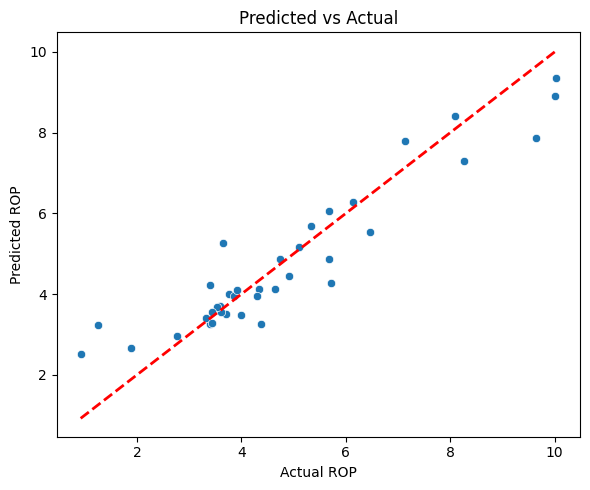

Saved predicted vs actual plot to predicted_vs_actual.png


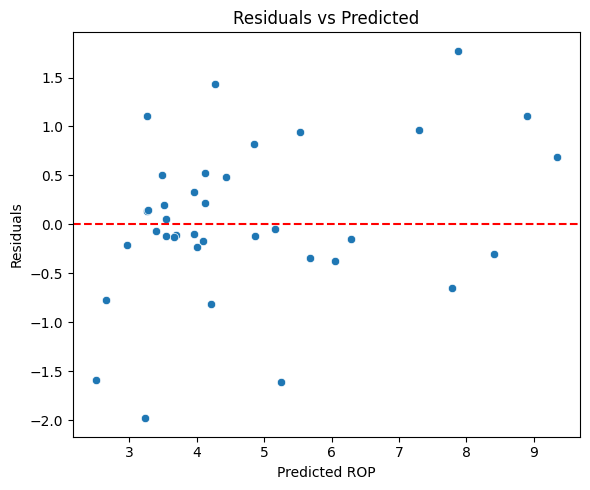

Saved residuals vs predicted plot to residuals_vs_predicted.png


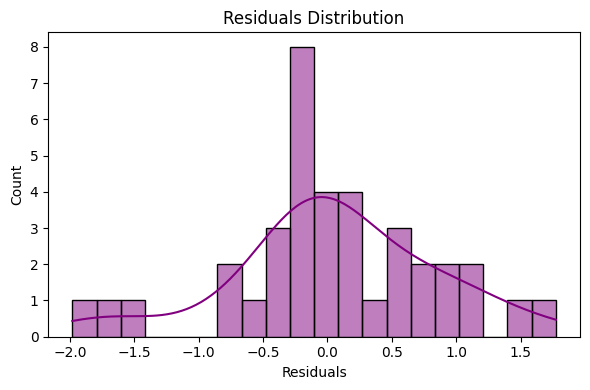

Saved residuals distribution plot to residuals_distribution.png


In [12]:
# 11. Residual analysis
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual ROP")
plt.ylabel("Predicted ROP")
plt.title("Predicted vs Actual")
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=300)
plt.show()
plt.close()
print("Saved predicted vs actual plot to predicted_vs_actual.png")

plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted ROP")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.savefig("residuals_vs_predicted.png", dpi=300)
plt.show()
plt.close()
print("Saved residuals vs predicted plot to residuals_vs_predicted.png")

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, color='purple', bins=20)
plt.xlabel("Residuals")
plt.title("Residuals Distribution")
plt.tight_layout()
plt.savefig("residuals_distribution.png", dpi=300)
plt.show()
plt.close()
print("Saved residuals distribution plot to residuals_distribution.png")



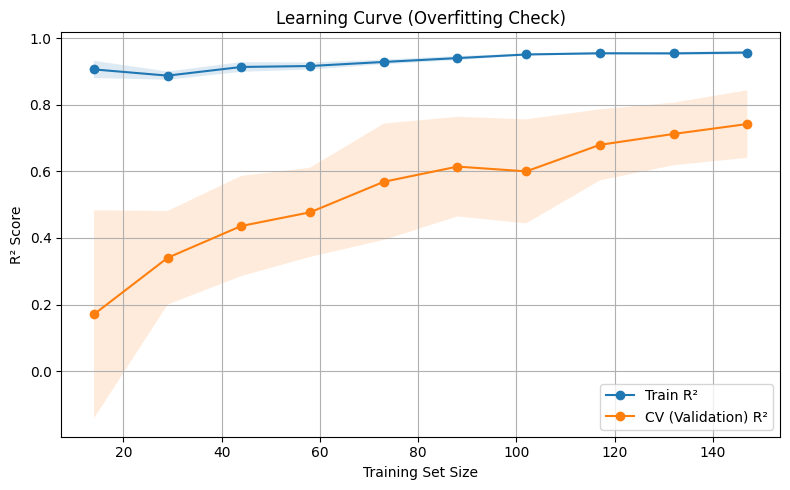

Saved Learning Curve as: learning_curve_r2.png
Train vs Test R² Comparison
Train R² : 0.9536
Test  R² : 0.8690
Gap (Train - Test) = 0.0846
Model generalization looks OK.


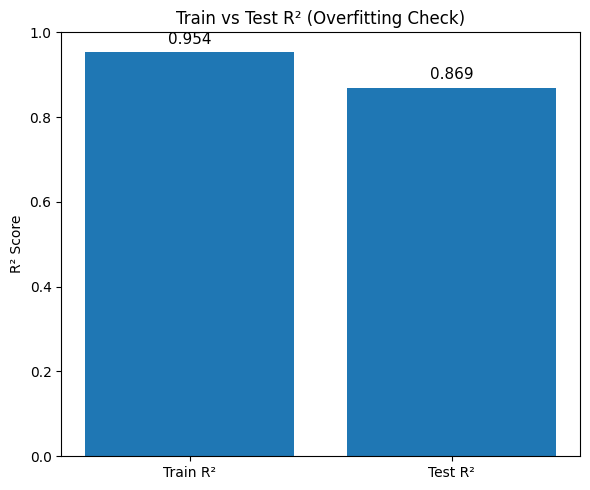

Saved Train vs Test R² plot as: train_vs_test_r2.png


(0.9536238886805759, 0.869035342142872)

In [13]:
# 12) Overfitting Check (Learning Curve + Train vs Test R² Plot)
def _resolve_estimator(model):
    if hasattr(model, "best_estimator_"):
        return model.best_estimator_
    return model


def _ensure_fitted(model, X_train, y_train):
    model = _resolve_estimator(model)
    try:
        model.predict(X_train.iloc[:2] if hasattr(X_train, "iloc") else X_train[:2])
    except Exception:
        print("Model not fitted yet → fitting now...")
        model.fit(X_train, y_train)
    return model


def plot_learning_curve_r2(model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10),
                           random_state=42, save_path="learning_curve_r2.png"):
    model = _resolve_estimator(model)


    if isinstance(cv, int):
        cv_obj = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    else:
        cv_obj = cv

    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=cv_obj,
        scoring="r2",
        train_sizes=train_sizes,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std  = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes_abs, train_mean, "o-", label="Train R²")
    plt.plot(train_sizes_abs, val_mean,  "o-", label="CV (Validation) R²")

    plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15)
    plt.fill_between(train_sizes_abs, val_mean - val_std,     val_mean + val_std,     alpha=0.15)

    plt.xlabel("Training Set Size")
    plt.ylabel("R² Score")
    plt.title("Learning Curve (Overfitting Check)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved Learning Curve as: {save_path}")

    return {
        "train_sizes": train_sizes_abs,
        "train_mean": train_mean,
        "train_std": train_std,
        "val_mean": val_mean,
        "val_std": val_std
    }


def train_test_r2_with_plot(model, X_train, X_test, y_train, y_test,
                            gap_threshold=0.15,
                            save_path="train_vs_test_r2.png"):
    model = _ensure_fitted(model, X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test  = r2_score(y_test, y_test_pred)
    gap = r2_train - r2_test

    print("Train vs Test R² Comparison")
    print(f"Train R² : {r2_train:.4f}")
    print(f"Test  R² : {r2_test:.4f}")
    print(f"Gap (Train - Test) = {gap:.4f}")

    if gap > gap_threshold:
        print("Model is likely OVERFITTING!")
    else:
        print("Model generalization looks OK.")


    plt.figure(figsize=(6, 5))
    labels = ["Train R²", "Test R²"]
    values = [r2_train, r2_test]

    plt.bar(labels, values)
    plt.ylim(0, 1)
    plt.ylabel("R² Score")
    plt.title("Train vs Test R² (Overfitting Check)")

    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=11)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved Train vs Test R² plot as: {save_path}")

    return r2_train, r2_test, 

plot_learning_curve_r2(best_model, X, y, cv=5)
train_test_r2_with_plot(best_model, X_train, X_test, y_train, y_test)


In [14]:
# 13. Feature importance / coefficients (safe + generalized)
print('\nFeature importances / coefficients (best model):')

# try to find final estimator for pipelines
try:
    model_core = best_model.named_steps['model']
except Exception:
    model_core = best_model

try:
    if hasattr(model_core, 'feature_importances_'):
        importances = model_core.feature_importances_
        for f, imp in zip(features, importances):
            print(f"{f}: {imp:.4f}")

    elif hasattr(model_core, 'coef_'):
        coefs = model_core.coef_
        # in case of multi-output: flatten
        coefs = np.asarray(coefs).ravel()
        for f, c in zip(features, coefs):
            print(f"{f}: {c:.4f}")

    else:
        print("Model does not provide simple importances/coefficients (OK for paper ensembles).")

except Exception as e:
    print('Could not extract importances/coefficients:', e)




Feature importances / coefficients (best model):
Q(m)  GPM: 0.3875
p(g): 0.0484
T(g): 0.1224
RPM: 0.0973
D(b): 0.0399
W.O.B: 0.0733
H: 0.2312



Running SHAP analysis...


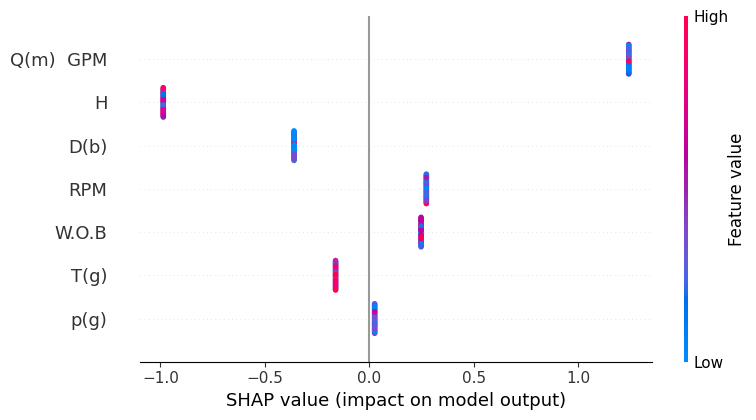

Saved SHAP summary plot to shap_summary.png


In [15]:

# 14. SHAP explanation (robust) 
print("\nRunning SHAP analysis...")

if SHAP_AVAILABLE:
    try:

        model_for_shap = model_core
        if hasattr(model_for_shap, "best_estimator_"):
            model_for_shap = model_for_shap.best_estimator_
        if hasattr(model_for_shap, "named_steps") and "model" in model_for_shap.named_steps:
            model_for_shap_core = model_for_shap.named_steps["model"]
            pre_for_shap = model_for_shap.named_steps.get("pre", None)
        else:
            model_for_shap_core = model_for_shap
            pre_for_shap = None

        X_train_df = pd.DataFrame(X_train, columns=features)
        X_test_df  = pd.DataFrame(X_test,  columns=features)


        if pre_for_shap is not None:
            X_train_trans = pre_for_shap.transform(X_train_df)
            X_test_trans  = pre_for_shap.transform(X_test_df)


            X_train_used = X_train_trans
            X_test_used  = X_test_trans
        else:
            X_train_used = X_train_df
            X_test_used  = X_test_df

        is_tree_like = hasattr(model_for_shap_core, "feature_importances_")

        if is_tree_like:
            explainer = shap.TreeExplainer(model_for_shap_core)
            shap_values = explainer.shap_values(X_test_used)
            shap.summary_plot(shap_values, X_test_used, show=False)
        else:
            background_size = min(20, len(X_train_used))
            explain_size    = min(80, len(X_test_used))

            if hasattr(shap, "kmeans"):
                background = shap.kmeans(X_train_used, background_size)
            else:
                background = X_train_used[:background_size]

            def predict_fn(x):
                return model_for_shap_core.predict(x)

            explainer = shap.KernelExplainer(predict_fn, background)
            shap_values = explainer.shap_values(X_test_used[:explain_size])

            shap.summary_plot(shap_values, X_test_used[:explain_size], show=False)

        plt.tight_layout()
        plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
        print("Saved SHAP summary plot to shap_summary.png")

    except Exception as e:
        print("SHAP analysis failed:", e)

else:
    print("SHAP not available. To enable: pip install shap")



Model comparison:
              model        r2       mse       mae
3      RandomForest  0.869035  0.618688  0.575965
4  GradientBoosting  0.849524  0.710863  0.648549
6           NN_Relu  0.842281  0.745077  0.629367
7        NN_Sigmoid  0.840789  0.752125  0.667249
5          AdaBoost  0.751781  1.172609  0.904333
0  LinearRegression  0.633878  1.729590  0.996550
1             Ridge  0.633559  1.731099  0.996611
2             Lasso  0.631317  1.741689  0.995813
Saved model comparison to model_comparison.csv


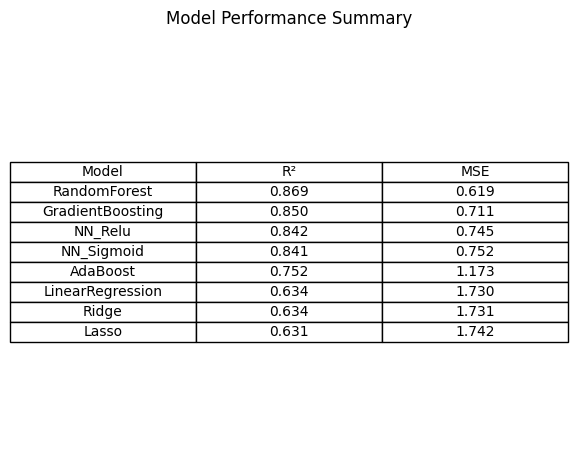

Saved model comparison image to model_comparison.png


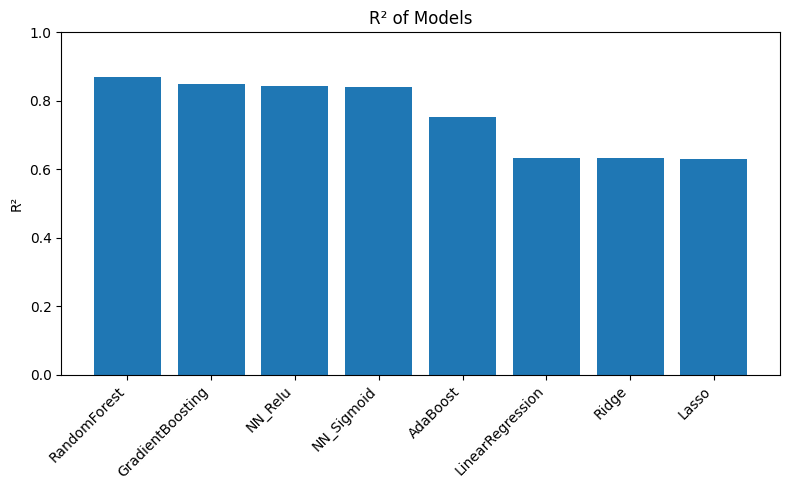

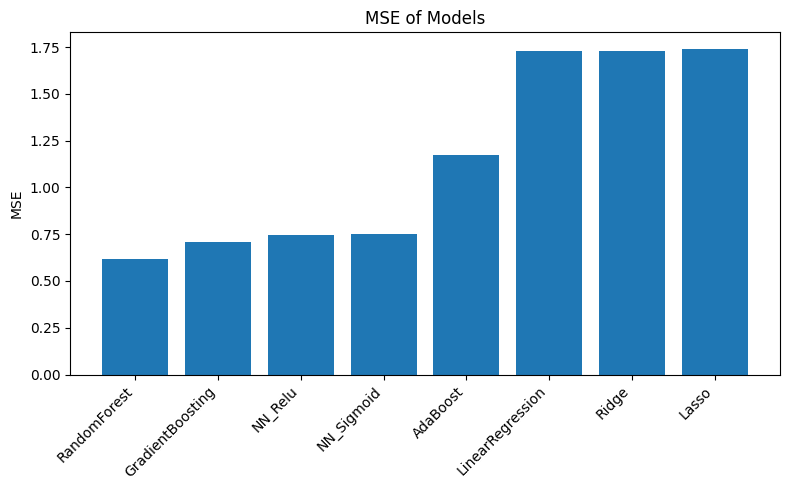

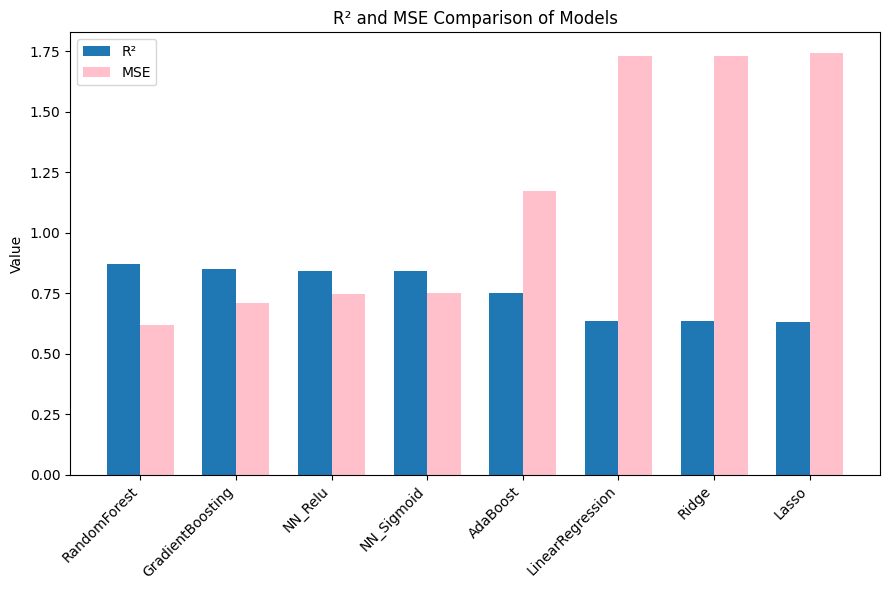

In [16]:
# 15. Export results summary as CSV, Image and Bar plots
summary_rows = []
for name, res in results.items():
    summary_rows.append({'model': name, 'r2': res['r2'], 'mse': res['mse'], 'mae': res['mae']})

summary_df = pd.DataFrame(summary_rows).sort_values('r2', ascending=False)
print('\nModel comparison:')
print(summary_df)

summary_df.to_csv('model_comparison.csv', index=False)
print('Saved model comparison to model_comparison.csv')

fig, ax = plt.subplots(figsize=(6, 2 + len(summary_df) * 0.4))
ax.axis('off')
table_data = [[row['model'], f"{row['r2']:.3f}", f"{row['mse']:.3f}"] for _, row in summary_df.iterrows()]
col_labels = ["Model", "R²", "MSE"]
table = ax.table(cellText=table_data, colLabels=col_labels, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.title("Model Performance Summary", pad=20)
plt.savefig("model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('Saved model comparison image to model_comparison.png')

plt.figure(figsize=(8, 5))
plt.bar(summary_df['model'], summary_df['r2'])
plt.ylabel('R²')
plt.ylim(0, 1)
plt.title('R² of Models')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("model_r2.png", dpi=300)
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
plt.bar(summary_df['model'], summary_df['mse'])
plt.ylabel('MSE')
plt.title('MSE of Models')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("model_mse.png", dpi=300)
plt.show()
plt.close()

models = summary_df['model']
r2_values = summary_df['r2']
mse_values = summary_df['mse']

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 6))
plt.bar(x - width/2, r2_values, width, label='R²')
plt.bar(x + width/2, mse_values, width, color='pink', label='MSE')
plt.ylabel('Value')
plt.title('R² and MSE Comparison of Models')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig("model_r2_mse_combined.png", dpi=300)
plt.show()
plt.close()



In [17]:
# 16. best operating point
print("Global optimization on best model (Operations Research style)")

feature_mins = X.min()
feature_maxs = X.max()

print("\nFeature ranges used as bounds in optimization:")
for f in features:
    print(f"  {f}: [{feature_mins[f]:.4f}, {feature_maxs[f]:.4f}]")

def objective(xvec):
    x_df = pd.DataFrame([xvec], columns=features)
    y_hat = best_model.predict(x_df)[0]
    return -y_hat  # maximize ROP

bounds = [(feature_mins[f], feature_maxs[f]) for f in features]

result = differential_evolution(
    objective,
    bounds,
    maxiter=500,
    tol=1e-6,
    seed=RANDOM_STATE
)

best_x = result.x
best_rop = -result.fun

print("\nOptimization finished.")
print(f"Success flag       : {result.success}")
print(f"Optimizer message  : {result.message}")

print("\nOptimal operating point (continuous search inside [min, max] of each feature):")
for f, val in zip(features, best_x):
    print(f"  {f:10s} = {val:10.4f}   (range [{feature_mins[f]:.4f}, {feature_maxs[f]:.4f}])")

print(f"\nPredicted MAX ROP by best_model ({best_model_name}): {best_rop:.4f}")

print("\n" + "-" * 70)
print("Comparing with the best existing sample in the dataset (according to model):")

X_with_pred = X.copy()
X_with_pred['pred_ROP'] = best_model.predict(X)

idx_max_sample = X_with_pred['pred_ROP'].idxmax()
best_sample = X_with_pred.loc[idx_max_sample]

print(f"\nBest existing sample index: {idx_max_sample}")
print("Feature values of best existing sample:")
for f in features:
    print(f"  {f:10s} = {best_sample[f]:10.4f}")

print(f"\nPredicted ROP for best existing sample: {best_sample['pred_ROP']:.4f}")




Global optimization on best model (Operations Research style)

Feature ranges used as bounds in optimization:
  Q(m)  GPM: [60.0000, 140.0000]
  p(g): [11.6182, 13.1877]
  T(g): [11.0000, 33.6000]
  RPM: [65.0000, 150.0000]
  D(b): [12.2500, 26.0000]
  W.O.B: [3.0000, 30.0000]
  H: [84.0000, 2404.0000]

Optimization finished.
Success flag       : True
Optimizer message  : Optimization terminated successfully.

Optimal operating point (continuous search inside [min, max] of each feature):
  Q(m)  GPM  =   110.1416   (range [60.0000, 140.0000])
  p(g)       =    12.3252   (range [11.6182, 13.1877])
  T(g)       =    21.0501   (range [11.0000, 33.6000])
  RPM        =   121.0735   (range [65.0000, 150.0000])
  D(b)       =    13.6405   (range [12.2500, 26.0000])
  W.O.B      =    17.6228   (range [3.0000, 30.0000])
  H          =  1331.4159   (range [84.0000, 2404.0000])

Predicted MAX ROP by best_model (RandomForest): 10.0751

-------------------------------------------------------------